<a href="https://colab.research.google.com/github/ashwini-ah18/Artificial-Intelligence/blob/main/Regression_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression with Keras
Project Objective: Build a model that predicts the power energy generated by a powerplant by considering the various sensor readings.
Change the runtime type to T4 GPU



In [2]:

import pandas as pd
path = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/PowerPlant.csv"
df = pd.read_csv(path)
df.head()



,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


Perform basic data quality checks

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.shape

(9568, 5)

In [5]:
## Check for duplicated information
df.duplicated().sum()


np.int64(41)

In [6]:
# drop duplicates to handle duplicated information
df = df.drop_duplicates()

In [7]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

Separate X and Y features
X : AT(Atmospheric temperature),V (vaccum), AP : Atmospheric pressure, RH: Relative Humidity

Y : PE (Power Energy)

In [8]:

X = df.drop(columns='PE')
Y = df[['PE']]

In [9]:

X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:

Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


Splitting the data into training and testing

In [11]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.80,random_state=21)

## Data cleaning and preprocessing
## perform data cleaning as well as scaling of numerical data

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipe = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler()).set_output(transform="pandas")

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler())])

In [13]:
num_pipe.fit(xtrain)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler())])

In [14]:
xtrain_pre = num_pipe.transform(xtrain)
xtest_pre = num_pipe.transform(xtest)


In [15]:

xtrain_pre.head()


,AT,V,AP,RH
4531,-1.689756,-1.063410,1.555170,1.203072
6736,0.305120,0.521433,0.776416,0.634907
8019,-1.576686,-1.024717,-0.801408,1.677905
5136,-0.297919,-0.263486,-0.178404,0.715976
857,-1.292665,-1.155010,1.296150,0.049030


## Model Building: Artificial Neural Network

In [17]:
xtrain.shape

(7621, 4)

In [18]:

xtrain.shape[1]

4

In [19]:
from keras.models import Sequential
from keras.layers import Input,Dense

# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer
model.add(Dense(units=8,activation='relu'))

# Add the output layer
model.add(Dense(units=1,activation='linear'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae'])

In [21]:
hist = model.fit(xtrain,ytrain,validation_split=0.2,epochs=50)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 396004.5625 - mae: 608.2870 - val_loss: 120883.3438 - val_mae: 346.7359
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37844.8828 - mae: 172.5899 - val_loss: 3745.4417 - val_mae: 54.6083
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1310.1361 - mae: 29.3662 - val_loss: 793.2276 - val_mae: 24.8587
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 781.2273 - mae: 24.6507 - val_loss: 769.2232 - val_mae: 24.6589
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 765.5935 - mae: 24.4344 - val_loss: 751.1896 - val_mae: 24.4146
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 748.6180 - mae: 24.1569 - val_loss: 732.7631 - val_mae: 24.1251
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 729.7308 - mae: 23.8670 - val_loss: 714.1105 - val_mae: 23.7790
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 708.3923 - mae: 23.5071 - val_loss: 692.4272 - val_mae: 23.

##Model Evaluation

## Learning Curve : to understand the behaviour of loss with increased number of epochs

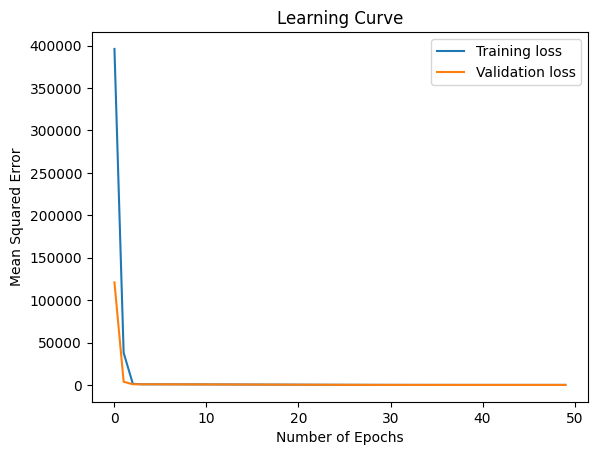

In [22]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'],label = "Training loss")
plt.plot(hist.history['val_loss'],label = "Validation loss")
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve")
plt.legend()
plt.show()


In [23]:
model.evaluate(xtrain,ytrain)

239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 30.9956 - mae: 4.3647


[30.995561599731445, 4.364741325378418]

In [24]:
model.evaluate(xtest,ytest)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30.5404 - mae: 4.3500


[30.540401458740234, 4.3499674797058105]

In [25]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
ypreds = model.predict(xtest)

# MSE,RMSE,MAE,R2 score
mse = mean_squared_error(ytest,ypreds)
rmse = mse**(1/2)
mae = mean_absolute_error(ytest,ypreds)
r2 = r2_score(ytest,ypreds)

print(f"MSE: {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE:{mae:.2f}")
print(f"R2 score:{r2*100:.2f}%")


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MSE: 30.54
RMSE : 5.53
MAE:4.35
R2 score:89.51%


##R2 score of 90.67% is a very good score. We can definitely consider this model for deployment

In [26]:
model.save("PowerEnergymodel.keras")

In [27]:
import joblib
joblib.dump(num_pipe,"Pipeline_data_cleaning_scaling.joblib")



['Pipeline_data_cleaning_scaling.joblib']

In [28]:
from keras.models import load_model

model_loaded = load_model(r"/content/PowerEnergymodel.keras")
model_loaded.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149 (600.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 100 (404.00 B)

In [29]:
pipeline = joblib.load(r"/content/Pipeline_data_cleaning_scaling.joblib")
pipeline


Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler())])

Example deployment scenario



In [30]:
path2 = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/PowerPlantTest.csv"
sample_data = pd.read_csv(path2)
sample_data

,AT,V,AP,RH
0,25,51.5,1000.1,57.0
1,32,41.0,1051.1,80.0
2,28,NaN,1010.2,NaN


**we handle data cleaning as well as scaling on the new data**

In [31]:
sample_cleaned = pipeline.transform(sample_data)
sample_cleaned

,AT,V,AP,RH
0,0.718363,-0.216107,-2.220095,-1.109781
1,1.660612,-1.045248,6.413920,0.457100
2,1.122184,0.000000,-0.510221,0.000000


### Model predictions

In [32]:

preds = model_loaded.predict(sample_cleaned)
preds = preds.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


In [33]:
preds

array([[-0.95],
       [ 2.09],
       [-0.33]], dtype=float32)

## Combine the predictions to the sample data and share it with the client

In [34]:

sample_data

,AT,V,AP,RH
0,25,51.5,1000.1,57.0
1,32,41.0,1051.1,80.0
2,28,NaN,1010.2,NaN


In [35]:
sample_data["PowerEnergy_Predicted"] = preds
sample_data


,AT,V,AP,RH,PowerEnergy_Predicted
0,25,51.5,1000.1,57.0,-0.95
1,32,41.0,1051.1,80.0,2.09
2,28,NaN,1010.2,NaN,-0.33


In [36]:

sample_data.to_csv("PE Predicted.csv",index=False)